# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [1]:
# Import the library
from PIL import Image, ImageOps
import numpy as np

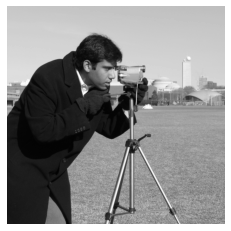

In [9]:
# ── Load image ────────────────────────────────────
from skimage import data
from PIL import Image
import matplotlib.pyplot as plt

# Get cameraman image
img = data.camera()

# Convert NumPy array to PIL Image
img = Image.fromarray(img)

# Show image
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [11]:
# Get the size of the image
width, height = img.size

# scaling factors
cx = 2
cy = 2

In [12]:
new_width = int(width * cx)
new_height = int(height * cy)

scaled_img = img.resize(
    (new_width, new_height),
    Image.LANCZOS
)

In [13]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
scaled_img.save("task1_1_scaled.jpg")

print("Original size:", img.size)
print("Scaled size:", scaled_img.size)

Original size: (512, 512)
Scaled size: (1024, 1024)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [15]:
cx = 2
cy = 1

new_width = int(width * cx)
new_height = int(height * cy)

stretched_img = img.resize(
    (new_width, new_height),
    Image.LANCZOS
)

### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

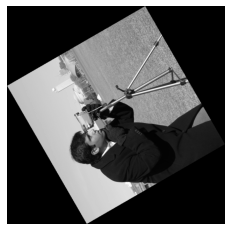

In [17]:
# ── 2. Rotate 120 degrees ──────────────────────────

rotated_img = img.rotate(
    120,
    resample=Image.BICUBIC,
    expand=True
)

rotated_img.save("task1_2_rotated.jpg")

# Show the rotated image
plt.imshow(rotated_img, cmap='gray')
plt.axis('off')
plt.show()

### 3. Shear

In [18]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size

In [19]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.

shx = 0.5
shy = 0

In [20]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

new_width = int(width + abs(shx) * height)

sheared_img = img.transform(
    (new_width, height),
    Image.AFFINE,
    (1, -shx, 0, 0, 1, 0),
    resample=Image.BICUBIC
)

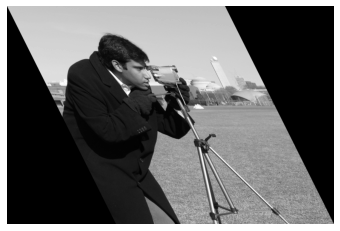

In [22]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 

sheared_img.save("task1_3_sheared.jpg")

plt.imshow(sheared_img, cmap='gray')
plt.axis('off')
plt.show()

### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

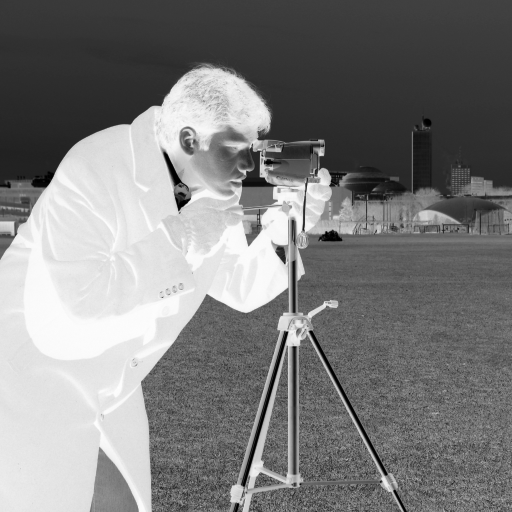

In [23]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation


img_array = np.array(img)

negative_array = 255 - img_array

negative_img = Image.fromarray(negative_array)

negative_img.save("negative_numpy.jpg")

display(negative_img)


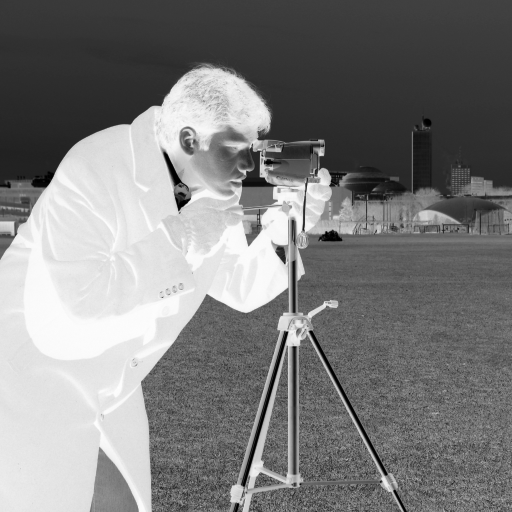

In [24]:
# Method 2: PIL's ImageOps
negative_pil = ImageOps.invert(img)

negative_pil.save("negative_pil.jpg")

display(negative_pil)

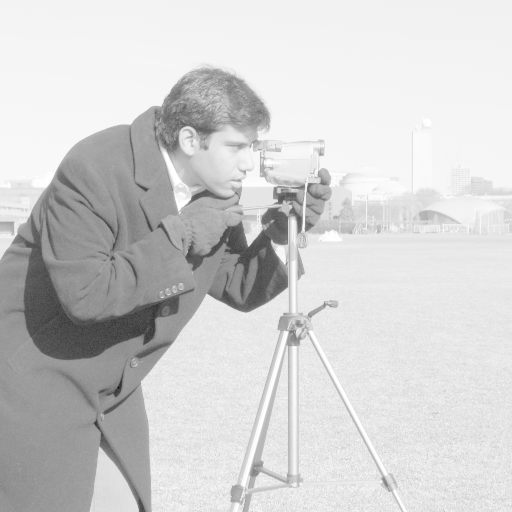

In [26]:
# ── 2. Log transformation ──────────────────────────

img_array = np.array(img).astype(float)

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255
# when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_array = c * np.log(1 + img_array)

# Convert values back to uint8
log_array = np.uint8(log_array)

# Convert array back to image
log_img = Image.fromarray(log_array)

# Save the image
log_img.save("log_transformation.jpg")

# Display the result
display(log_img)


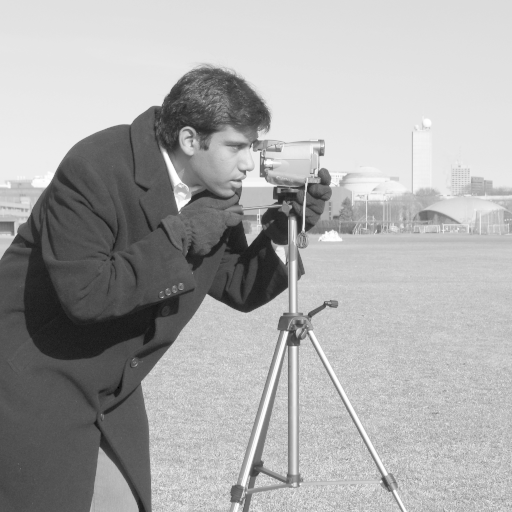

In [27]:

# ── 3. Power-law / Gamma correction ───────────────
gamma = 0.5

# Convert image to NumPy array and normalize to range 0-1
img_array = np.array(img).astype(float) / 255.0

# Apply gamma transformation
gamma_array = np.power(img_array, gamma)

# Convert back to range 0-255
gamma_array = np.uint8(gamma_array * 255)

# Convert array back to image
gamma_img = Image.fromarray(gamma_array)

# Save the image
gamma_img.save("gamma_correction.jpg")

# Display the result
display(gamma_img)
